# Chapter 10

In [1]:
import pandas as pd 
import numpy as np 
from scipy import stats
import matplotlib.pyplot as plt 

### Table 10.1, Table 10.2, Table 10.3

In [2]:
df_T1001 = pd.DataFrame({
    'test': np.arange(8)+1,
    'temp': ['-', '+'] * 4,
    'conc': (['-']*2 + ['+']*2)*2,
    'catalyst': ['-']*4 + ['+']*4,
    'yield_average': [60,72,54,68,52,83,45,80], # averages of two replicates
    'yield_1': [59,74,50,69,50,81,46,79],
    'yield_2': [61,70,58,67,54,85,44,81],
})

In [3]:
df_T1001['replicate_difference'] = df_T1001['yield_1'] - df_T1001['yield_2']
df_T1001['set_variance'] = (df_T1001['replicate_difference']**2) / 2 # s2 = diff^2 / 2, special for 2 replicates

In [4]:
df_T1001

,test,temp,conc,catalyst,yield_average,yield_1,yield_2,replicate_difference,set_variance
0,1,-,-,-,60,59,61,-2,2.0
1,2,+,-,-,72,74,70,4,8.0
2,3,-,+,-,54,50,58,-8,32.0
3,4,+,+,-,68,69,67,2,2.0
4,5,-,-,+,52,50,54,-4,8.0
5,6,+,-,+,83,81,85,-4,8.0
6,7,-,+,+,45,46,44,2,2.0
7,8,+,+,+,80,79,81,-2,2.0


In [5]:
# s2 = pooled estimate of sigma**2 = average of estimated variances with degrees of freedom of 8
s2_T1001 = df_T1001['set_variance'].sum() / 8 # treat it as the population variance
np.sqrt(s2_T1001/16) # all sample mean standard effor

np.float64(0.7071067811865476)

In [6]:
# V(effect): variance of each effect = V(y_bar_+ - y_bar_-)
# either y_bar_+ or y_bar_- is calculated from 8 observations (here is the sample mean var, so it is population var divided by sample size), 
# so both of their sample mean variance s2 = sigma2 (s2 calculated above) / 8

var_effect_T1002 = s2_T1001/8 + s2_T1001/8 # 
var_effect_T1002 = 4/16 * s2_T1001 # a more direct way to calculate it
np.sqrt(var_effect_T1002) # standar error of effect

# In general, if a total of N runs is made in conducting a two-level factorial or replicated factorial design
# then V(effect) = sigma**2 / (N/2) + sigma**2 / (N/2) = 4 * sigma**2 / N
# same as above: V(effect): variance of each effect = V(y_bar_+ - y_bar_-), sample size of each y_bar is N/2

np.float64(1.4142135623730951)

### Exercise 10.3

In [7]:
# E 10.3
df_E1003 = pd.DataFrame({
    'test': np.arange(8),
    'brand': ['-', '+'] * 4,
    'ratio': (['-']*2 + ['+']*2)*2,
    'size': ['-']*4 + ['+']*4,
    'yield': [6.25,8,6,9.5,8,15,9,17],
})

In [8]:
brand_effect_E1003 = df_E1003.groupby('brand')['yield'].mean().diff(-1).values[0]
brand_effect_E1003

np.float64(5.0625)

In [9]:
ratio_effect_E1003 = df_E1003.groupby('ratio')['yield'].mean().diff(-1).values[0]

In [10]:
size_effect_E1003 = df_E1003.groupby('size')['yield'].mean().diff(-1).values[0]

In [11]:
brand_ratio_effect_E1003 = df_E1003.groupby(['brand', 'ratio'])['yield'].mean().diff(-2).diff(-1)/2
brand_ratio_effect_E1003 = brand_ratio_effect_E1003.values[0]

In [12]:
brand_size_effect_E1003 = df_E1003.groupby(['brand', 'size'])['yield'].mean().diff(-2).diff(-1)/2
brand_size_effect_E1003 = brand_size_effect_E1003.values[0]

In [13]:
ratio_size_effect_E1003 = df_E1003.groupby(['ratio', 'size'])['yield'].mean().diff(-2).diff(-1)/2
ratio_size_effect_E1003 = ratio_size_effect_E1003.values[0]

In [14]:
brand_ratio_size_effect_E1003 = df_E1003.groupby(['brand', 'ratio','size'])['yield'].mean().diff(-4).diff(-2).diff(-1)/4
brand_ratio_size_effect_E1003 = brand_ratio_size_effect_E1003.values[0]
brand_ratio_size_effect_E1003

np.float64(-0.1875)

### Exercise 10.4

In [15]:
signs = np.array(['-', '+'])
df_E1004 = pd.DataFrame({
    'test': np.arange(8),
    'depth': signs[np.tile(np.arange(2), 4)],
    'watering': signs[np.tile(np.repeat(np.arange(2),2),2)],
    'type': signs[np.repeat(np.arange(2),4)],
    'yield_1': [6,4,10,7,4,3,8,5],
    'yield_2': [7,5,9,7,5,3,7,5],
    'yield_3': [6,5,8,6,4,1,7,4],
})

In [16]:
df_E1004['yield_average'] = df_E1004[['yield_1', 'yield_2', 'yield_3']].mean(axis=1)

In [17]:
df_E1004.groupby('depth')['yield_average'].mean().diff(-1)

depth
+   -2.166667
-         NaN
Name: yield_average, dtype: float64

In [18]:
df_E1004.groupby('watering')['yield_average'].mean().diff(-1)

watering
+    2.5
-    NaN
Name: yield_average, dtype: float64

In [19]:
df_E1004.groupby('type')['yield_average'].mean().diff(-1)

type
+   -2.0
-    NaN
Name: yield_average, dtype: float64

In [20]:
df_E1004.groupby(['depth','watering'])['yield_average'].mean().diff(-2).diff(-1) / 2

depth  watering
+      +          -0.333333
       -                NaN
-      +                NaN
       -                NaN
Name: yield_average, dtype: float64

In [21]:
df_E1004.groupby(['depth','type'])['yield_average'].mean().diff(-2).diff(-1)/2

depth  type
+      +      -0.166667
       -            NaN
-      +            NaN
       -            NaN
Name: yield_average, dtype: float64

In [22]:
df_E1004.groupby(['watering','type'])['yield_average'].mean().diff(-2).diff(-1)/2

watering  type
+         +       0.166667
          -            NaN
-         +            NaN
          -            NaN
Name: yield_average, dtype: float64

In [23]:
df_E1004.groupby(['depth','watering','type'])['yield_average'].mean().diff(-4).diff(-2).diff(-1) / 4

depth  watering  type
+      +         +       1.110223e-16
                 -                NaN
       -         +                NaN
                 -                NaN
-      +         +                NaN
                 -                NaN
       -         +                NaN
                 -                NaN
Name: yield_average, dtype: float64

In [24]:
df_E1004['yield_s2'] = df_E1004[['yield_1','yield_2','yield_3']].var(axis=1, ddof=1) # sample mean variance
df_E1004['dof'] = [2]*8 # degrees of freedom


In [25]:
s2_E1004 = (df_E1004['yield_s2']*df_E1004['dof']).sum() / df_E1004['dof'].sum() # estimated variance
se_mean_E1004 = np.sqrt(s2_E1004/24) # standard error of the mean
se_effect_E1004 = np.sqrt(2*s2_E1004/12) # standard error of the effect. 
# difference of y_bar+ and y_bar-, each of which consists of 12 tests, so the varaince of each is mean variance/12, 
# then add up to get the effect variance
se_mean_E1004,se_effect_E1004

(np.float64(0.1502313031443329), np.float64(0.3004626062886658))

### Exercise 10.5

In [26]:
df_E1005 = df_E1004[df_E1004.columns[:6]]
df_E1005.columns = pd.MultiIndex.from_arrays([['']+['factors']*3+['yield']*2, df_E1005.columns])
# df_E1005['yield']['yield_average'] = df_E1005['yield'].mean(axis=

In [27]:
for i in range(df_E1005.factors.shape[1]):
    print(df_E1005.factors.columns[i])
    print(df_E1005.groupby(('factors', df_E1005.factors.columns[i]))['yield'].mean().mean(axis=1).diff(-1).values[0])

for i in range(df_E1005.factors.shape[1]-1):
    for j in range(i+1,df_E1005.factors.shape[1]):
        print(df_E1005.factors.columns[i], df_E1005.factors.columns[j])
        print(df_E1005.groupby([('factors', df_E1005.factors.columns[i]),('factors', df_E1005.factors.columns[j])])['yield'].mean().mean(axis=1).diff(-2).diff(-1).values[0]/2)

print(df_E1005.factors.columns,
      df_E1005.groupby([('factors',df_E1005.factors.columns[0]), ('factors',df_E1005.factors.columns[1]) ,('factors',df_E1005.factors.columns[2])])['yield'].mean().mean(axis=1).diff(-4).diff(-2).diff(-1).values[0]/4)


depth
-2.125
watering
2.625
type
-1.875
depth watering
-0.375
depth type
0.125
watering type
-0.125
Index(['depth', 'watering', 'type'], dtype='str') -0.125


In [28]:
df_E1005['var'] = df_E1005['yield'].var(axis=1,ddof=1)

In [29]:
var_mean_E1005 = df_E1005['var'].sum()/8
var_mean_E1005

np.float64(0.3125)

In [30]:
var_effect_E1005 = 4/16*var_mean_E1005
var_effect_E1005

np.float64(0.078125)

In [31]:
se_effect_E1005 = np.sqrt(var_effect_E1005)
se_effect_E1005

np.float64(0.2795084971874737)

### Excercise 10.6

In [32]:
df_E1003

,test,brand,ratio,size,yield
0,0,-,-,-,6.25
1,1,+,-,-,8.00
2,2,-,+,-,6.00
3,3,+,+,-,9.50
4,4,-,-,+,8.00
5,5,+,-,+,15.00
6,6,-,+,+,9.00
7,7,+,+,+,17.00


In [33]:
extra_yield_E1006 = np.array([9,8,9.5,10])
s2_E1004 = extra_yield_E1006.var(ddof=1)
s2_E1004 # this then can be treated as the population var to calculate the effect vars

np.float64(0.7291666666666666)

In [34]:
se_effect_E1006 = np.sqrt(s2_E1004 * 4 / 8)

[Text(5.0625, 0.0, 'brand_effect_E1003'),
 Text(4.8125, 0.02, 'size_effect_E1003'),
 Text(1.0625, 0.04, 'ratio_effect_E1003'),
 Text(0.6875, 0.06, 'brand_ratio_effect_E1003'),
 Text(2.4375, 0.08, 'brand_size_effect_E1003'),
 Text(0.4375, 0.1, 'ratio_size_effect_E1003'),
 Text(-0.1875, 0.12, 'brand_ratio_size_effect_E1003')]

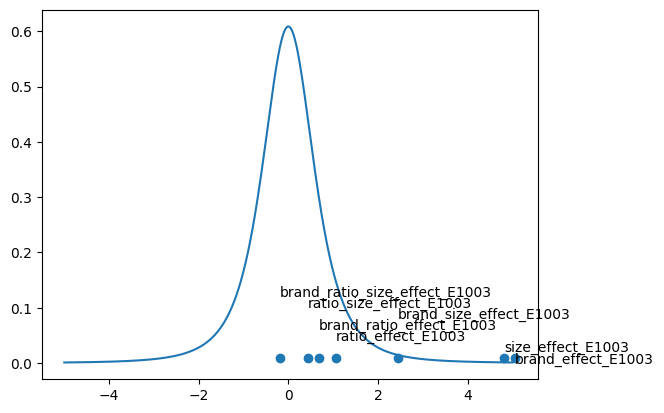

In [35]:
range_E1006 = 5
x_E1006 = np.linspace(-range_E1006, range_E1006, 1001)
plt.plot(x_E1006, stats.t.pdf(x_E1006, df=3, scale=se_effect_E1006))
plt.scatter([brand_effect_E1003, size_effect_E1003, ratio_effect_E1003, brand_ratio_effect_E1003, brand_size_effect_E1003, ratio_size_effect_E1003, brand_ratio_size_effect_E1003],
            [0.01]*7)
[plt.text(x,y,s) for x,y,s in zip([brand_effect_E1003, size_effect_E1003, ratio_effect_E1003, brand_ratio_effect_E1003, brand_size_effect_E1003, ratio_size_effect_E1003, brand_ratio_size_effect_E1003],
            [0.02*i for i in range(7)],
            'brand_effect_E1003, size_effect_E1003, ratio_effect_E1003, brand_ratio_effect_E1003, brand_size_effect_E1003, ratio_size_effect_E1003, brand_ratio_size_effect_E1003'.split(', '))]


### Exercise 10.8

In [36]:
df_T1001

,test,temp,conc,catalyst,yield_average,yield_1,yield_2,replicate_difference,set_variance
0,1,-,-,-,60,59,61,-2,2.0
1,2,+,-,-,72,74,70,4,8.0
2,3,-,+,-,54,50,58,-8,32.0
3,4,+,+,-,68,69,67,2,2.0
4,5,-,-,+,52,50,54,-4,8.0
5,6,+,-,+,83,81,85,-4,8.0
6,7,-,+,+,45,46,44,2,2.0
7,8,+,+,+,80,79,81,-2,2.0


In [37]:
conc_E1007 = df_T1001.groupby('conc')['yield_average'].mean().diff(-1).values[0]
conc_E1007

np.float64(-5.0)

In [38]:
temp_E1007 = df_T1001.groupby('temp')['yield_average'].mean().diff(-1).values[0]
temp_E1007

np.float64(23.0)

In [39]:
catalyst_E1007 = df_T1001.groupby('catalyst')['yield_average'].mean().diff(-1).values[0]
catalyst_E1007

np.float64(1.5)

In [40]:
conc_temp_E1007 = df_T1001.groupby(['conc', 'temp'])['yield_average'].mean().diff(-2).diff(-1).values[0] / 2
conc_temp_E1007

np.float64(1.5)

In [41]:
conc_catalyst_E1007 = df_T1001.groupby(['conc', 'catalyst'])['yield_average'].mean().diff(-2).diff(-1).values[0] / 2
conc_catalyst_E1007

np.float64(0.0)

In [42]:
catalyst_temp_E1007 = df_T1001.groupby(['catalyst', 'temp'])['yield_average'].mean().diff(-2).diff(-1).values[0] / 2
catalyst_temp_E1007

np.float64(10.0)

In [43]:
conc_catalyst_temp_E1007 = df_T1001.groupby(['conc', 'catalyst', 'temp'])['yield_average'].mean().diff(-4).diff(-2).diff(-1).values[0] / 4
conc_catalyst_temp_E1007

np.float64(0.5)

In [44]:
df_T1001

,test,temp,conc,catalyst,yield_average,yield_1,yield_2,replicate_difference,set_variance
0,1,-,-,-,60,59,61,-2,2.0
1,2,+,-,-,72,74,70,4,8.0
2,3,-,+,-,54,50,58,-8,32.0
3,4,+,+,-,68,69,67,2,2.0
4,5,-,-,+,52,50,54,-4,8.0
5,6,+,-,+,83,81,85,-4,8.0
6,7,-,+,+,45,46,44,2,2.0
7,8,+,+,+,80,79,81,-2,2.0


In [45]:
df_E1008 = pd.concat((df_T1001[['test', 'yield_1']], df_T1001[['test', 'yield_2']]))
df_E1008['yield'] = df_E1008[['yield_1', 'yield_2']].sum(axis=1)

In [46]:
df_E1008['ave'] = df_E1008['yield'].mean()
df_E1008['test_dev'] = df_E1008.groupby('test')['yield'].transform('mean') - df_E1008['ave']
df_E1008['residual'] = df_E1008['yield'] - df_E1008['ave'] - df_E1008['test_dev']
df_E1008

,test,yield_1,yield_2,yield,ave,test_dev,residual
0,1,59.0,NaN,59.0,64.25,-4.25,-1.0
1,2,74.0,NaN,74.0,64.25,7.75,2.0
2,3,50.0,NaN,50.0,64.25,-10.25,-4.0
3,4,69.0,NaN,69.0,64.25,3.75,1.0
4,5,50.0,NaN,50.0,64.25,-12.25,-2.0
5,6,81.0,NaN,81.0,64.25,18.75,-2.0
6,7,46.0,NaN,46.0,64.25,-19.25,1.0
7,8,79.0,NaN,79.0,64.25,15.75,-1.0
0,1,NaN,61.0,61.0,64.25,-4.25,1.0
1,2,NaN,70.0,70.0,64.25,7.75,-2.0


In [47]:
(df_E1008['residual']**2).sum()

np.float64(64.0)

### Problem 10.10

In [66]:
[[i+1, (-1)**(i+1), (-1)**(i//2 + 1), (-1)**(i//4 + 1), (-1)**(i//8 + 1)] for i in range(16)]

[[1, -1, -1, -1, -1],
 [2, 1, -1, -1, -1],
 [3, -1, 1, -1, -1],
 [4, 1, 1, -1, -1],
 [5, -1, -1, 1, -1],
 [6, 1, -1, 1, -1],
 [7, -1, 1, 1, -1],
 [8, 1, 1, 1, -1],
 [9, -1, -1, -1, 1],
 [10, 1, -1, -1, 1],
 [11, -1, 1, -1, 1],
 [12, 1, 1, -1, 1],
 [13, -1, -1, 1, 1],
 [14, 1, -1, 1, 1],
 [15, -1, 1, 1, 1],
 [16, 1, 1, 1, 1]]

In [67]:
df_E1010 = pd.DataFrame([[i+1, (-1)**(i+1), (-1)**(i//2 + 1), (-1)**(i//4 + 1), (-1)**(i//8 + 1)] for i in range(16)], columns=['#', '1', '2', '3', '4'])
df_E1010['conversion'] = [71,61,90,82,68,61,87,80,61,50,89,83,59,51,85,78]
df_E1010

,#,1,2,3,4,conversion
0,1,-1,-1,-1,-1,71
1,2,1,-1,-1,-1,61
2,3,-1,1,-1,-1,90
3,4,1,1,-1,-1,82
4,5,-1,-1,1,-1,68
5,6,1,-1,1,-1,61
6,7,-1,1,1,-1,87
7,8,1,1,1,-1,80
8,9,-1,-1,-1,1,61
9,10,1,-1,-1,1,50


In [68]:
from itertools import combinations
factors_E1010 = df_E1010.columns[1:5]
interactions_E1010 = []
for r in range(2,len(factors_E1010)+1):
    interactions_E1010.extend(combinations(factors_E1010, r))

interactions_E1010

[('1', '2'),
 ('1', '3'),
 ('1', '4'),
 ('2', '3'),
 ('2', '4'),
 ('3', '4'),
 ('1', '2', '3'),
 ('1', '2', '4'),
 ('1', '3', '4'),
 ('2', '3', '4'),
 ('1', '2', '3', '4')]

In [69]:
for interaction in interactions_E1010:
    df_E1010[''.join(interaction)] = df_E1010[list(interaction)].prod(axis=1)

df_E1010

,#,1,2,3,4,conversion,12,13,14,23,24,34,123,124,134,234,1234
0,1,-1,-1,-1,-1,71,1,1,1,1,1,1,-1,-1,-1,-1,1
1,2,1,-1,-1,-1,61,-1,-1,-1,1,1,1,1,1,1,-1,-1
2,3,-1,1,-1,-1,90,-1,1,1,-1,-1,1,1,1,-1,1,-1
3,4,1,1,-1,-1,82,1,-1,-1,-1,-1,1,-1,-1,1,1,1
4,5,-1,-1,1,-1,68,1,-1,1,-1,1,-1,1,-1,1,1,-1
5,6,1,-1,1,-1,61,-1,1,-1,-1,1,-1,-1,1,-1,1,1
6,7,-1,1,1,-1,87,-1,-1,1,1,-1,-1,-1,1,1,-1,1
7,8,1,1,1,-1,80,1,1,-1,1,-1,-1,1,-1,-1,-1,-1
8,9,-1,-1,-1,1,61,1,1,-1,1,-1,-1,-1,1,1,1,-1
9,10,1,-1,-1,1,50,-1,-1,1,1,-1,-1,1,-1,-1,1,1


In [70]:
df_E1010['ave'] = [1]*16
df_E1010

,#,1,2,3,4,conversion,12,13,14,23,24,34,123,124,134,234,1234,ave
0,1,-1,-1,-1,-1,71,1,1,1,1,1,1,-1,-1,-1,-1,1,1
1,2,1,-1,-1,-1,61,-1,-1,-1,1,1,1,1,1,1,-1,-1,1
2,3,-1,1,-1,-1,90,-1,1,1,-1,-1,1,1,1,-1,1,-1,1
3,4,1,1,-1,-1,82,1,-1,-1,-1,-1,1,-1,-1,1,1,1,1
4,5,-1,-1,1,-1,68,1,-1,1,-1,1,-1,1,-1,1,1,-1,1
5,6,1,-1,1,-1,61,-1,1,-1,-1,1,-1,-1,1,-1,1,1,1
6,7,-1,1,1,-1,87,-1,-1,1,1,-1,-1,-1,1,1,-1,1,1
7,8,1,1,1,-1,80,1,1,-1,1,-1,-1,1,-1,-1,-1,-1,1
8,9,-1,-1,-1,1,61,1,1,-1,1,-1,-1,-1,1,1,1,-1,1
9,10,1,-1,-1,1,50,-1,-1,1,1,-1,-1,1,-1,-1,1,1,1


In [85]:
df_E1010_effects = (df_E1010[df_E1010.columns[[i for i in range(1, 18) if i!=5]]].multiply(df_E1010['conversion'], axis=0).sum() / 8).to_frame(name='estimated_effects')

In [88]:
df_E1010_effects.loc['ave'] = df_E1010_effects.loc['ave'] / 2

In [89]:
df_E1010_effects

,estimated_effects
1,-8.00
2,24.00
3,-2.25
4,-5.50
12,1.00
13,0.75
14,0.00
23,-1.25
24,4.50
34,-0.25


In [99]:
(df_E1010_effects.loc[df_E1010_effects.index[-6:-1]]**2).sum() / 5 # sum of square divied by 5 degrees of freedom as a measure of effect variance, which is 0.3
# standard error of effect is 
np.sqrt(0.3)

np.float64(0.5477225575051661)

In [100]:
# recall that ave is obtained by divided by 16, but other effect by 8, so
# standard error of ave is 
np.sqrt(0.3) / 2


np.float64(0.27386127875258304)

### Problem 10.11

In [164]:
df_E1011 = pd.merge(pd.DataFrame({'quality': [58,44,55,45,55,42,56,46,51,45,58,44,60,46,54,45],
                                  'ave': [1]*16}, index=np.arange(16)+1),
         pd.DataFrame([[(-1)**(i//2**j + 1) for j in range(4)] for i in range(16)], columns=[i for i in '1234'], index=np.arange(16)+1),
         left_index=True, right_index=True
         )


In [165]:
from itertools import combinations
factors_E1011 = [i for i in '1234']
interactions_E1011 = []
[interactions_E1011.extend(list(combinations(factors_E1011, r+1))) for r in range(1,len(factors_E1011))]

interactions_E1011

[('1', '2'),
 ('1', '3'),
 ('1', '4'),
 ('2', '3'),
 ('2', '4'),
 ('3', '4'),
 ('1', '2', '3'),
 ('1', '2', '4'),
 ('1', '3', '4'),
 ('2', '3', '4'),
 ('1', '2', '3', '4')]

In [166]:
for interaction in interactions_E1011:
    df_E1011[''.join(interaction)] = df_E1011[list(interaction)].prod(axis=1) 

df_E1011

,quality,ave,1,2,3,4,12,13,14,23,24,34,123,124,134,234,1234
1,58,1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1,-1,-1,1
2,44,1,1,-1,-1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1
3,55,1,-1,1,-1,-1,-1,1,1,-1,-1,1,1,1,-1,1,-1
4,45,1,1,1,-1,-1,1,-1,-1,-1,-1,1,-1,-1,1,1,1
5,55,1,-1,-1,1,-1,1,-1,1,-1,1,-1,1,-1,1,1,-1
6,42,1,1,-1,1,-1,-1,1,-1,-1,1,-1,-1,1,-1,1,1
7,56,1,-1,1,1,-1,-1,-1,1,1,-1,-1,-1,1,1,-1,1
8,46,1,1,1,1,-1,1,1,-1,1,-1,-1,1,-1,-1,-1,-1
9,51,1,-1,-1,-1,1,1,1,-1,1,-1,-1,-1,1,1,1,-1
10,45,1,1,-1,-1,1,-1,-1,1,1,-1,-1,1,-1,-1,1,1


In [167]:
df_E1011_effects = (df_E1011.iloc[:,1:].multiply(df_E1011['quality'], axis=0)).sum().to_frame(name='estimated_effects') / 8
df_E1011_effects.loc['ave'] = df_E1011_effects.loc['ave'] / 2

df_E1011_effects

,estimated_effects
ave,50.25
1,-11.25
2,0.25
3,0.50
4,0.25
12,0.50
13,-0.25
14,0.50
23,-0.75
24,-0.50


In [168]:
# get the sum of squares, then mean square as the variance with degree of freedom of 5, then take the sqareroot to get the effect SE, then divided by 2 to get the ave SE
np.sqrt((df_E1011_effects.iloc[-5:]**2).mean()), np.sqrt((df_E1011_effects.iloc[-5:]**2).mean()) / 2

(estimated_effects    1.635543
 dtype: float64,
 estimated_effects    0.817771
 dtype: float64)

[Text(-11.25, 0.02, '1'),
 Text(0.25, 0.02, '2'),
 Text(0.5, 0.02, '3'),
 Text(0.25, 0.02, '4'),
 Text(0.5, 0.02, '12'),
 Text(-0.25, 0.02, '13'),
 Text(0.5, 0.02, '14'),
 Text(-0.75, 0.02, '23'),
 Text(-0.5, 0.02, '24'),
 Text(1.25, 0.02, '34'),
 Text(1.5, 0.02, '123'),
 Text(-1.25, 0.02, '124'),
 Text(-0.5, 0.02, '134'),
 Text(-2.5, 0.02, '234'),
 Text(1.75, 0.02, '1234')]

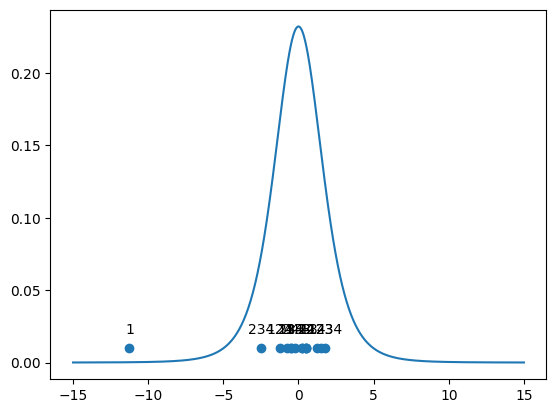

In [171]:
range_E1011 = 15
plt.plot(np.linspace(-range_E1011, range_E1011, 1001), stats.t.pdf(np.linspace(-range_E1011, range_E1011, 1001), scale=np.sqrt((df_E1011_effects.iloc[-5:]**2).mean()), df=5))
plt.scatter(df_E1011_effects['estimated_effects'][1:], [0.01]*15)
[plt.text(x,y,s,ha='center') for x,y,s in zip(df_E1011_effects['estimated_effects'][1:], [0.02]*15, df_E1011_effects.index[1:])]

In [190]:
df_norm_prob_E1011 = df_E1011_effects['estimated_effects'][1:].sort_values().to_frame(name='estimated_effects')
df_norm_prob_E1011['pct'] = [1/15 * (i-0.5) for i in range(1,16)]
df_norm_prob_E1011

,estimated_effects,pct
1,-11.25,0.033333
234,-2.50,0.100000
124,-1.25,0.166667
23,-0.75,0.233333
24,-0.50,0.300000
134,-0.50,0.366667
13,-0.25,0.433333
2,0.25,0.500000
4,0.25,0.566667
14,0.50,0.633333


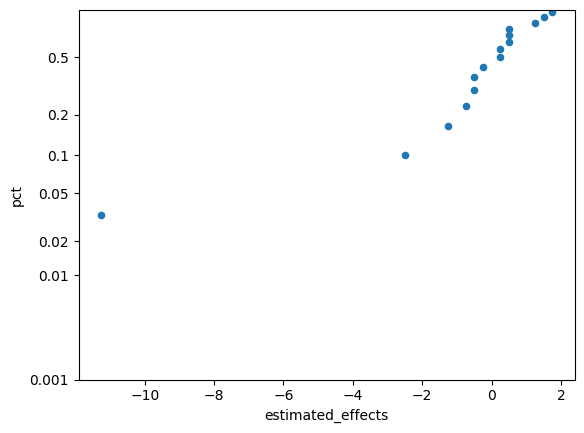

In [234]:
ax_E1011 = df_norm_prob_E1011.plot.scatter(x='estimated_effects', y='pct')
# [ax_E1011.text(x,y,s) for x,y,s in zip(df_norm_prob_E1011['estimated_effects'], df_norm_prob_E1011['pct'], df_norm_prob_E1011.index)]
import probscale
ax_E1011.set_ylim(0.001,0.999)
ax_E1011.set_yscale('prob')

### Problem 10.12

In [200]:
df_E1012 = pd.merge(pd.DataFrame({'conversion': [71,70,99,82,68,70,96,80,70,50,89,92,68,51,85,87],
                                  'ave': [1]*16}, index=np.arange(16)+1),
         pd.DataFrame([[(-1)**(i+1), (-1)**(i//2 + 1), (-1)**(i//4 + 1), (-1)**(i//8 + 1)] for i in range(16)], columns=['1', '2', '3', '4'], index=np.arange(16)+1),
        left_index=True, right_index=True
)

df_E1012

,conversion,ave,1,2,3,4
1,71,1,-1,-1,-1,-1
2,70,1,1,-1,-1,-1
3,99,1,-1,1,-1,-1
4,82,1,1,1,-1,-1
5,68,1,-1,-1,1,-1
6,70,1,1,-1,1,-1
7,96,1,-1,1,1,-1
8,80,1,1,1,1,-1
9,70,1,-1,-1,-1,1
10,50,1,1,-1,-1,1


In [203]:
from itertools import combinations
factors_E1012= [i for i in '1234']
interactions_E1012 = []
for r in range(2,5):
    interactions_E1012.extend(combinations(factors_E1012, r))

interactions_E1012

[('1', '2'),
 ('1', '3'),
 ('1', '4'),
 ('2', '3'),
 ('2', '4'),
 ('3', '4'),
 ('1', '2', '3'),
 ('1', '2', '4'),
 ('1', '3', '4'),
 ('2', '3', '4'),
 ('1', '2', '3', '4')]

In [205]:
for interaction in interactions_E1012:
    df_E1012[''.join(interaction)] = df_E1012[list(interaction)].prod(axis=1)

df_E1012

,conversion,ave,1,2,3,4,12,13,14,23,24,34,123,124,134,234,1234
1,71,1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1,-1,-1,1
2,70,1,1,-1,-1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1
3,99,1,-1,1,-1,-1,-1,1,1,-1,-1,1,1,1,-1,1,-1
4,82,1,1,1,-1,-1,1,-1,-1,-1,-1,1,-1,-1,1,1,1
5,68,1,-1,-1,1,-1,1,-1,1,-1,1,-1,1,-1,1,1,-1
6,70,1,1,-1,1,-1,-1,1,-1,-1,1,-1,-1,1,-1,1,1
7,96,1,-1,1,1,-1,-1,-1,1,1,-1,-1,-1,1,1,-1,1
8,80,1,1,1,1,-1,1,1,-1,1,-1,-1,1,-1,-1,-1,-1
9,70,1,-1,-1,-1,1,1,1,-1,1,-1,-1,-1,1,1,1,-1
10,50,1,1,-1,-1,1,-1,-1,1,1,-1,-1,1,-1,-1,1,1


In [218]:
df_E1012_effects = (df_E1012.iloc[:,1:].multiply(df_E1012['conversion'], axis=0).sum() / 8).to_frame(name='estimated_effects')
df_E1012_effects.loc['ave'] = df_E1012_effects.loc['ave'] / 2

df_E1012_effects

,estimated_effects
ave,76.75
1,-8.00
2,24.00
3,-2.25
4,-5.50
12,1.00
13,0.75
14,0.00
23,-1.25
24,4.50


In [219]:
# standard error of effect by the high order interactions 3 and 4-order
np.sqrt((df_E1012_effects.iloc[-5:]**2).mean()) # root of mean square is the estimate of the effect standard error

estimated_effects    4.27785
dtype: float64

[Text(-8.0, 0.02, '1'),
 Text(24.0, 0.02, '2'),
 Text(-2.25, 0.02, '3'),
 Text(-5.5, 0.02, '4'),
 Text(1.0, 0.02, '12'),
 Text(0.75, 0.02, '13'),
 Text(0.0, 0.02, '14'),
 Text(-1.25, 0.02, '23'),
 Text(4.5, 0.02, '24'),
 Text(-0.25, 0.02, '34'),
 Text(-0.75, 0.02, '123'),
 Text(9.5, 0.02, '124'),
 Text(-0.25, 0.02, '134'),
 Text(-0.75, 0.02, '234'),
 Text(-0.25, 0.02, '1234')]

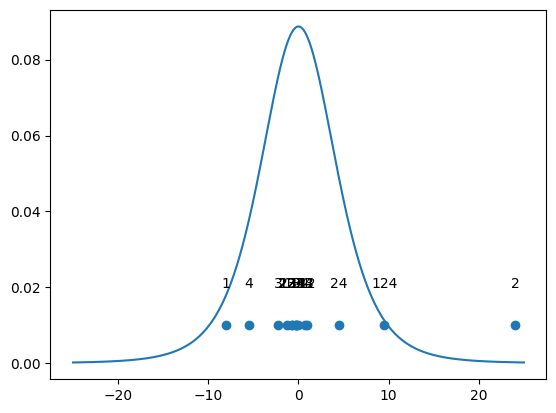

In [224]:
# now this is no appropriate to use high order interations to evaluate the standard error as clearly interaction *124* is not just error
range_E1012 = 25

plt.plot(np.linspace(-range_E1012, range_E1012, 1001), stats.t.pdf(np.linspace(-range_E1012, range_E1012, 1001), df=5, scale=np.sqrt((df_E1012_effects.iloc[-5:]**2).mean())))
plt.scatter(df_E1012_effects.iloc[1:]['estimated_effects'], [0.01]*15)
[plt.text(x,y,s, ha='center') for x,y,s in zip(df_E1012_effects.iloc[1:]['estimated_effects'], [0.02]*15, df_E1012_effects.index[1:])]

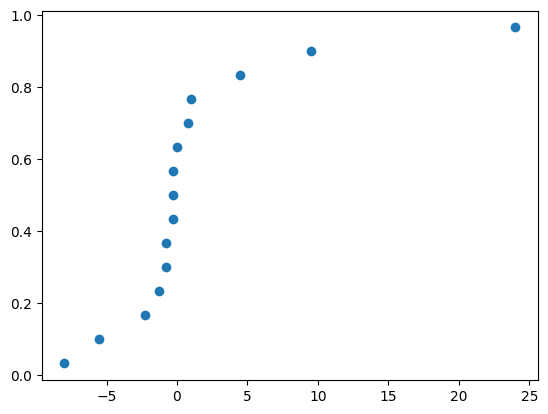

In [245]:
# use the normal plot
plt.scatter(df_E1012_effects.iloc[1:]['estimated_effects'].sort_values(), [1/15 * (i+0.5) for i in range(15)])
# stats.probplot(df_E1012_effects.iloc[1:]['estimated_effects'].sort_values(), rvalue=True, plot=plt)
# plt.yscale('prob')

([<matplotlib.axis.YTick at 0x18f5d7da210>,
 [Text(0, -1.2815515655446004, '0.1'),
  Text(0, -0.8416212335729142, '0.2'),
  Text(0, -0.5244005127080407, '0.3'),
  Text(0, -0.2533471031357997, '0.4'),
  Text(0, 0.0, '0.5'),
  Text(0, 0.2533471031357997, '0.6'),
  Text(0, 0.524400512708041, '0.7'),
  Text(0, 0.8416212335729143, '0.8'),
  Text(0, 1.2815515655446004, '0.9')])

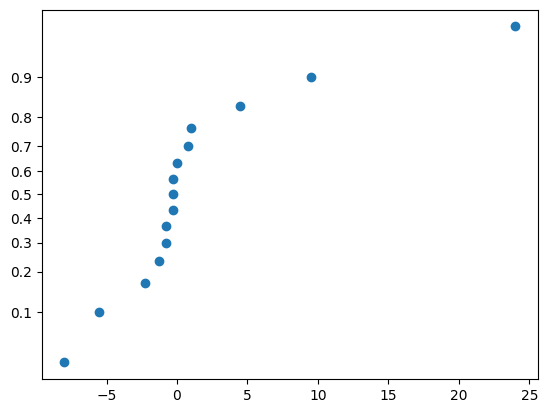

In [265]:
plt.scatter(df_E1012_effects.iloc[1:]['estimated_effects'].sort_values(), stats.norm.ppf(np.arange(1/30,1,1/15)))
plt.yticks(stats.norm.ppf(np.arange(0.1 ,1, 0.1)), np.arange(0.1,1, 0.1).round(1))

### Table 10B.2

In [275]:
df_T10b2 = pd.DataFrame([[(-1)**(i//(2**j) + 1) for j in range(6)] for i in range(64)], columns=[i for i in '123456'], index=np.arange(64)+1)

In [278]:
blocks_T10b2 = ['135', '1256', '1234']
for block in blocks_T10b2:
    df_T10b2[block] = df_T10b2[[i for i in block]].prod(axis=1)

df_T10b2

,1,2,3,4,5,6,135,1256,1234
1,-1,-1,-1,-1,-1,-1,-1,1,1
2,1,-1,-1,-1,-1,-1,1,-1,-1
3,-1,1,-1,-1,-1,-1,-1,-1,-1
4,1,1,-1,-1,-1,-1,1,1,1
5,-1,-1,1,-1,-1,-1,1,1,-1
...,...,...,...,...,...,...,...,...,...
60,1,1,-1,1,1,1,-1,1,-1
61,-1,-1,1,1,1,1,-1,1,1
62,1,-1,1,1,1,1,1,-1,-1
63,-1,1,1,1,1,1,-1,-1,-1


In [285]:
df_T10b2['block#'] = ((df_T10b2[blocks_T10b2]+1)/2).apply(lambda row: int(row['135'] + row['1256'] * 2 + row['1234'] * 2**2 + 1), axis=1)

In [294]:
df_T10b2 = df_T10b2.reset_index(names=['exp_num'])

In [309]:
df_T10b2 = df_T10b2.sort_values(by=['block#', 'exp_num'])

In [ ]:
df_T10b2

,exp_num,1,2,3,4,5,6,135,1256,1234,block#
2,3,-1,1,-1,-1,-1,-1,-1,-1,-1,1
13,14,1,-1,1,1,-1,-1,-1,-1,-1,1
20,21,-1,-1,1,-1,1,-1,-1,-1,-1,1
27,28,1,1,-1,1,1,-1,-1,-1,-1,1
39,40,1,1,1,-1,-1,1,-1,-1,-1,1
...,...,...,...,...,...,...,...,...,...,...,...
26,27,-1,1,-1,1,1,-1,1,1,1,8
38,39,-1,1,1,-1,-1,1,1,1,1,8
41,42,1,-1,-1,1,-1,1,1,1,1,8
48,49,-1,-1,-1,-1,1,1,1,1,1,8
